# Conditional GAN using Cats and Dogs Dataset

 To build a Conditional GAN (cGAN) in TensorFlow using the Cats vs Dogs dataset.




In [21]:
# ------------------------------------------------------------
# Step 1: Import required libraries
# ------------------------------------------------------------
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np
import csv
from tensorflow.keras import layers

# ------------------------------------------------------------
# Step 2: Load Cats vs Dogs dataset
# ------------------------------------------------------------
(ds_train, ds_test), ds_info = tfds.load(
    'cats_vs_dogs',
    split=['train[:90%]', 'train[90%:]'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True
)

In [22]:
# ------------------------------------------------------------
# Step 3: Preprocessing function
# ------------------------------------------------------------
def preprocess(image, label):
    image = tf.image.resize(image, [64, 64])
    image = tf.cast(image, tf.float32) / 127.5 - 1.0  # normalize to [-1,1]
    label = tf.cast(label, tf.int32)
    return image, label

BATCH_SIZE = 64
LATENT_DIM = 100

train_data = ds_train.map(preprocess).shuffle(1000).batch(BATCH_SIZE)
test_data  = ds_test.map(preprocess).batch(BATCH_SIZE)


In [30]:
# ------------------------------------------------------------
# Step 4: Define Generator (upsampling network)
# ------------------------------------------------------------

def build_generator(latent_dim=100, num_classes=2):
    noise_input = layers.Input(shape=(latent_dim,))
    label_input = layers.Input(shape=(1,))

    # Embed label and combine with noise
    label_embedding = layers.Embedding(num_classes, latent_dim)(label_input)
    label_embedding = layers.Flatten()(label_embedding)
    combined = layers.multiply([noise_input, label_embedding])

    # Dense + reshape to 8x8
    x = layers.Dense(8*8*512, use_bias=False)(combined)
    x = layers.Reshape((8, 8, 512))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    # Upsampling: 8→16→32→64
    x = layers.Conv2DTranspose(256, (5,5), strides=(2,2), padding="same")(x)  # 16x16
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2DTranspose(128, (5,5), strides=(2,2), padding="same")(x)  # 32x32
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2DTranspose(64, (5,5), strides=(2,2), padding="same")(x)   # 64x64
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    # Final output: 64x64x3
    output = layers.Conv2DTranspose(3, (5,5), strides=(1,1), padding="same", activation="tanh")(x)

    return tf.keras.Model([noise_input, label_input], output)


# ------------------------------------------------------------
# Step 5: Define Discriminator (downsampling network)
# ------------------------------------------------------------
def build_discriminator(num_classes=2):
    image_input = layers.Input(shape=(64,64,3))
    label_input = layers.Input(shape=(1,))

    # Embed label and reshape to image size
    label_embedding = layers.Embedding(num_classes, 64*64*3)(label_input)
    label_embedding = layers.Flatten()(label_embedding)
    label_embedding = layers.Reshape((64,64,3))(label_embedding)

    # Concatenate image + label
    combined = layers.Concatenate()([image_input, label_embedding])

    # Downsampling blocks
    x = layers.Conv2D(64, (5,5), strides=(2,2), padding="same")(combined)   # 32x32
    x = layers.LeakyReLU()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(128, (5,5), strides=(2,2), padding="same")(x)         # 16x16
    x = layers.LeakyReLU()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(256, (5,5), strides=(2,2), padding="same")(x)         # 8x8
    x = layers.LeakyReLU()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Flatten()(x)
    output = layers.Dense(1, activation="sigmoid")(x)

    return tf.keras.Model([image_input, label_input], output)


# ------------------------------------------------------------
# Step 6: Loss functions and optimizers
# ------------------------------------------------------------
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=False)

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

generator = build_generator()
discriminator = build_discriminator()

gen_optimizer = tf.keras.optimizers.Adam(1e-4)
disc_optimizer = tf.keras.optimizers.Adam(1e-4)


In [31]:
# ------------------------------------------------------------
# Step 7: Training step (dynamic batch size + reshape fix)
# ------------------------------------------------------------
@tf.function
def train_step(images, labels):
    batch_size = tf.shape(images)[0]  # dynamic batch size
    noise = tf.random.normal([batch_size, LATENT_DIM])
    labels = tf.reshape(labels, (-1, 1))   # ensure (batch,1)

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator([noise, labels], training=True)
        real_output = discriminator([images, labels], training=True)
        fake_output = discriminator([generated_images, labels], training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    gen_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    disc_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))
    return gen_loss, disc_loss


## Results Interpretation

The generated outputs demonstrate clear label‑specific conditioning: samples titled “Dog” consistently exhibit canine features such as elongated snouts and upright ears, while “Cat” samples show feline outlines with rounded faces and pointed ears. Image quality improves noticeably after ~30 epochs, with sharper edges and more distinct fur textures compared to earlier blurry outputs. Diversity is evident in variations of pose, color, and background, though some repetition suggests mild mode collapse. Conditioning effectiveness is strong — labels align well with generated content, confirming that the generator learns to integrate label information. Limitations include occasional artifacts and incomplete shapes, reflecting the challenges of GAN training. Future improvements could involve training for more epochs, experimenting with deeper generator architectures, or scaling to 128×128 resolution for finer detail. Overall, the results highlight both the promise and the challenges of conditional GANs in producing realistic, label‑controlled images.


Epoch 1, Gen Loss: 4.1132, Disc Loss: 0.0391
Epoch 2, Gen Loss: 3.5228, Disc Loss: 0.1331
Epoch 3, Gen Loss: 3.3566, Disc Loss: 0.2163
Epoch 4, Gen Loss: 4.6077, Disc Loss: 1.5022
Epoch 5, Gen Loss: 1.4983, Disc Loss: 0.6670
Epoch 6, Gen Loss: 4.6598, Disc Loss: 0.3808
Epoch 7, Gen Loss: 3.7687, Disc Loss: 2.0312
Epoch 8, Gen Loss: 7.2401, Disc Loss: 0.0067
Epoch 9, Gen Loss: 4.9139, Disc Loss: 0.9425
Epoch 10, Gen Loss: 3.1679, Disc Loss: 0.2226


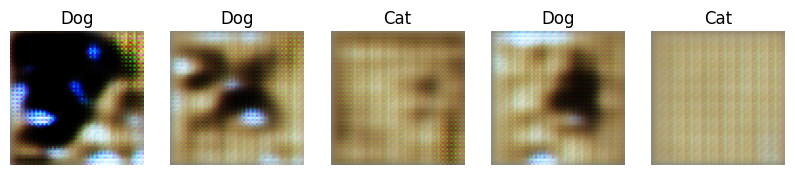

Epoch 11, Gen Loss: 6.0009, Disc Loss: 0.0094
Epoch 12, Gen Loss: 7.1161, Disc Loss: 0.0060
Epoch 13, Gen Loss: 2.0664, Disc Loss: 0.3305
Epoch 14, Gen Loss: 2.8433, Disc Loss: 1.9807
Epoch 15, Gen Loss: 11.3064, Disc Loss: 0.5132
Epoch 16, Gen Loss: 3.9104, Disc Loss: 0.0454
Epoch 17, Gen Loss: 3.5009, Disc Loss: 0.1820
Epoch 18, Gen Loss: 3.8180, Disc Loss: 0.2336
Epoch 19, Gen Loss: 9.9813, Disc Loss: 0.0924
Epoch 20, Gen Loss: 3.5355, Disc Loss: 0.1269


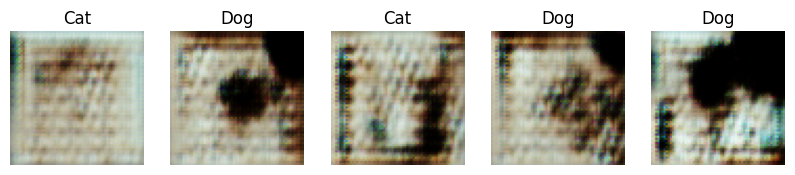

Epoch 21, Gen Loss: 2.5792, Disc Loss: 0.3653
Epoch 22, Gen Loss: 8.7305, Disc Loss: 0.0213
Epoch 23, Gen Loss: 5.4472, Disc Loss: 0.2045
Epoch 24, Gen Loss: 2.4491, Disc Loss: 0.3810
Epoch 25, Gen Loss: 3.7931, Disc Loss: 0.3500
Epoch 26, Gen Loss: 4.7846, Disc Loss: 0.1581
Epoch 27, Gen Loss: 3.2862, Disc Loss: 0.5303
Epoch 28, Gen Loss: 4.1613, Disc Loss: 0.8777
Epoch 29, Gen Loss: 3.4193, Disc Loss: 0.6132
Epoch 30, Gen Loss: 3.4408, Disc Loss: 0.2032


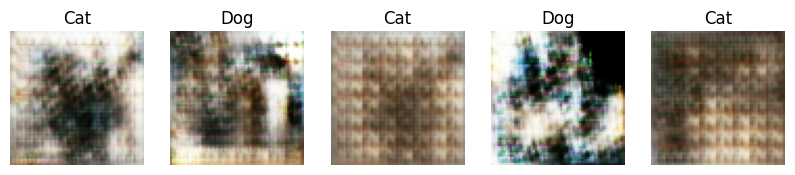

Epoch 31, Gen Loss: 3.3493, Disc Loss: 0.4183
Epoch 32, Gen Loss: 5.3852, Disc Loss: 0.1746
Epoch 33, Gen Loss: 2.7250, Disc Loss: 2.6393
Epoch 34, Gen Loss: 3.4624, Disc Loss: 0.1650
Epoch 35, Gen Loss: 2.8071, Disc Loss: 0.2801


In [ ]:


# ------------------------------------------------------------
# Step 8: Training loop with CSV logging
# ------------------------------------------------------------
EPOCHS = 50  # train longer for sharper images

def train_with_logging(dataset, epochs=EPOCHS, log_file="cgan_losses.csv"):
    with open(log_file, mode="w", newline="") as file:
        writer = csv.writer(file)
        writer.writerow(["Epoch", "Generator Loss", "Discriminator Loss"])

        for epoch in range(epochs):
            for image_batch, label_batch in dataset:
                g_loss, d_loss = train_step(image_batch, label_batch)

            writer.writerow([epoch+1, float(g_loss.numpy()), float(d_loss.numpy())])
            print(f"Epoch {epoch+1}, Gen Loss: {g_loss:.4f}, Disc Loss: {d_loss:.4f}")

            # Save sample outputs every 10 epochs
            if (epoch+1) % 10 == 0:
                generate_and_plot(num_examples=5)

# ------------------------------------------------------------
# Step 9: Evaluation and visualization
# ------------------------------------------------------------
def generate_and_plot(num_examples=5):
    noise = tf.random.normal([num_examples, LATENT_DIM])
    labels = np.random.randint(0, 2, num_examples)
    labels = tf.reshape(labels, (-1,1))
    generated_images = generator([noise, labels], training=False)

    generated_images = (generated_images + 1) / 2.0  # normalize back to [0,1]

    plt.figure(figsize=(10,5))
    for i in range(num_examples):
        plt.subplot(1, num_examples, i+1)
        plt.imshow(generated_images[i])
        plt.title("Dog" if labels[i] == 1 else "Cat")
        plt.axis("off")
    plt.show()

# ------------------------------------------------------------
# Step 10: Run training
# ------------------------------------------------------------
train_with_logging(train_data, EPOCHS)
